In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [ ]:
import pandas as pd

df = pd.read_excel("Sample - Superstore.xlsx")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Sample - Superstore.xlsx'

In [ ]:
import os

print(os.listdir())

['.config', 'Sample - Superstore.csv', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding='cp1252')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Shape: (9994, 21)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             ob

In [ ]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


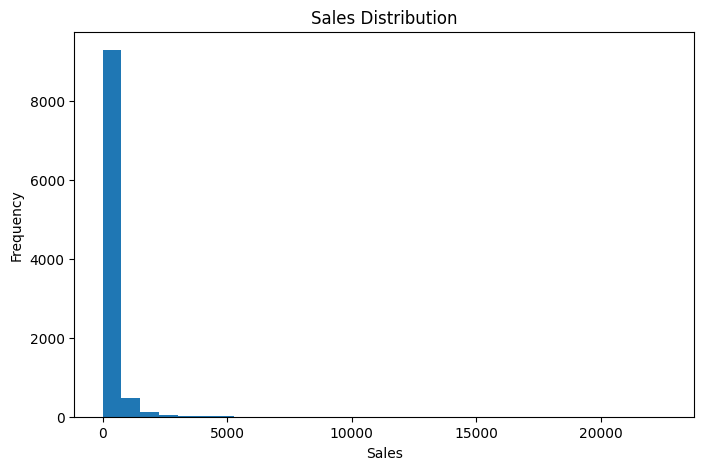

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins=30)
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

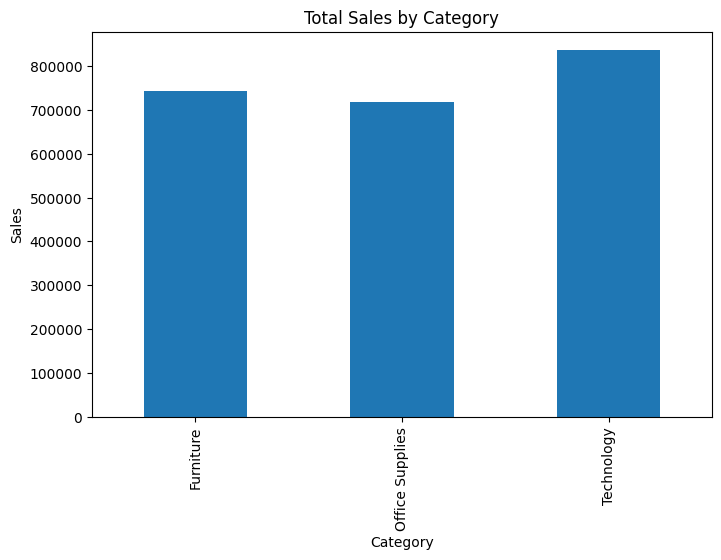

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title('Total Sales by Category')
plt.ylabel('Sales')
plt.show()

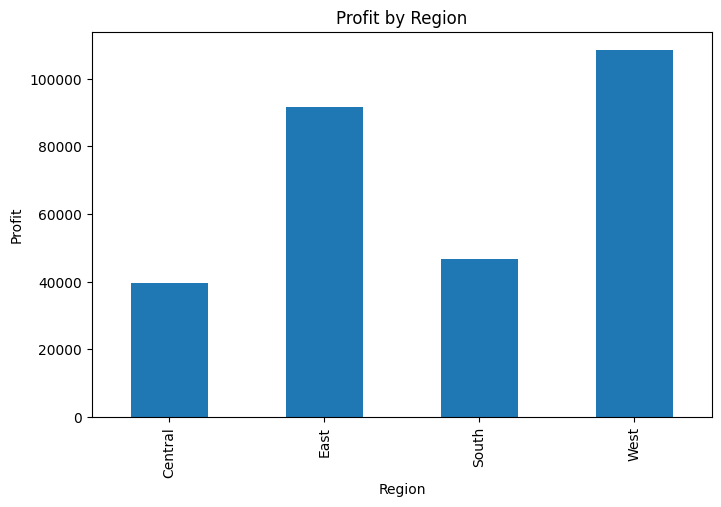

In [ ]:
region_profit = df.groupby('Region')['Profit'].sum()

plt.figure(figsize=(8,5))
region_profit.plot(kind='bar')
plt.title('Profit by Region')
plt.ylabel('Profit')
plt.show()

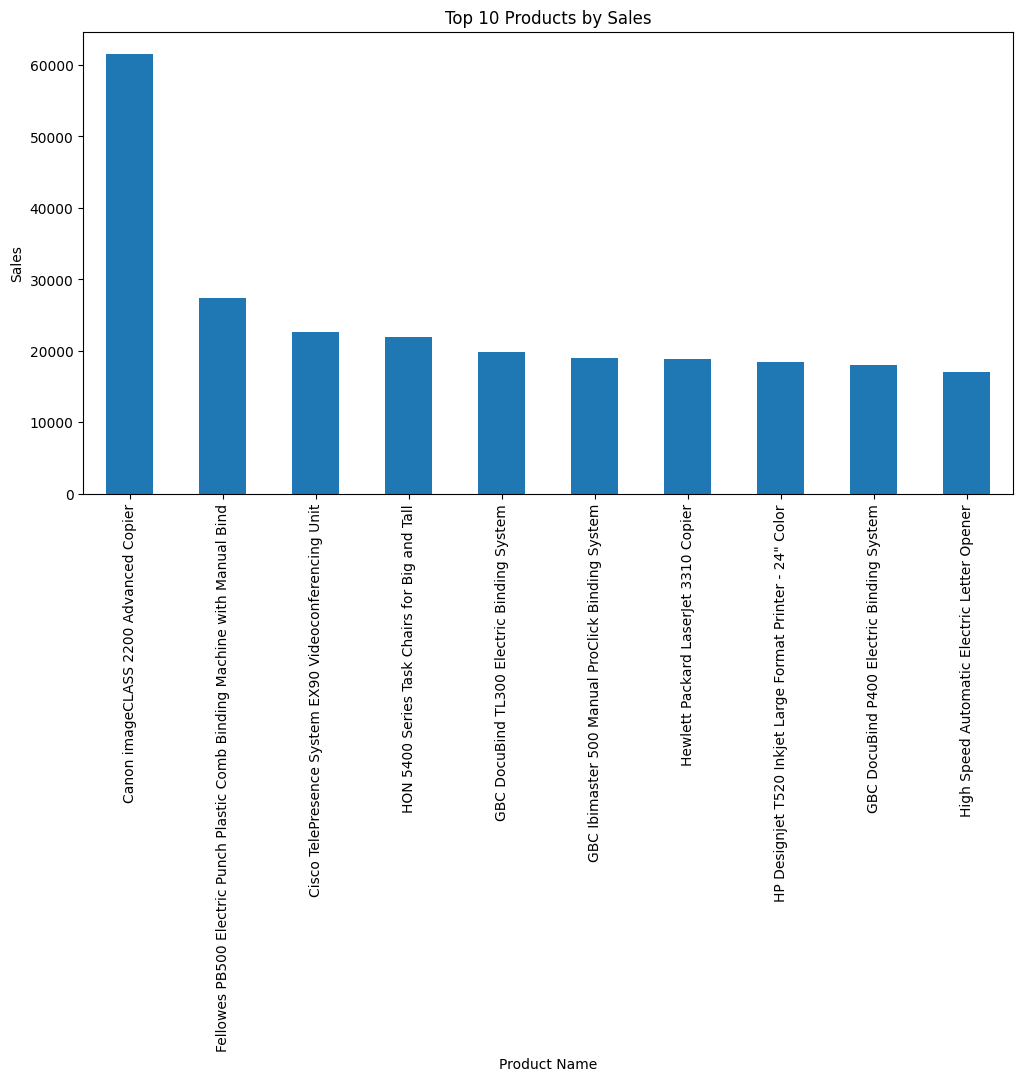

In [ ]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_products.plot(kind='bar')
plt.title('Top 10 Products by Sales')
plt.ylabel('Sales')
plt.show()

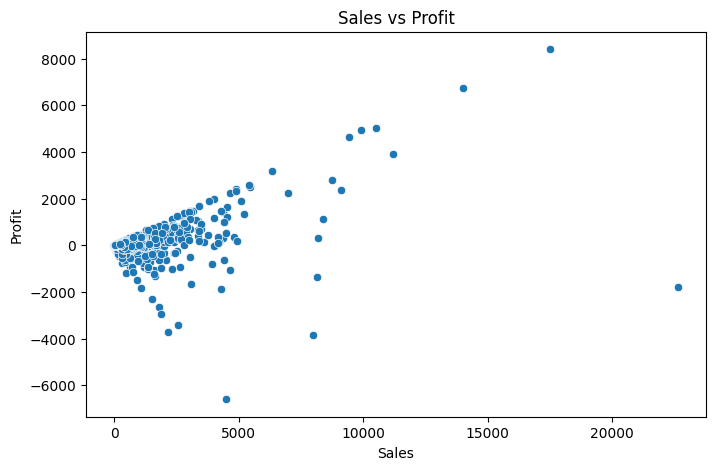

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Sales', y='Profit')
plt.title('Sales vs Profit')
plt.show()

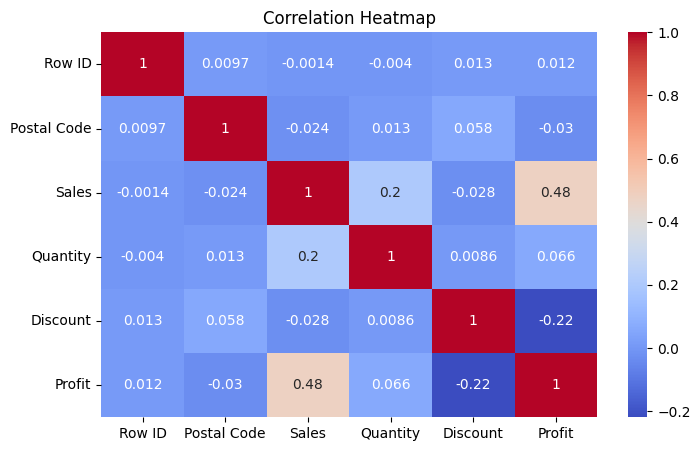

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
print("Total Sales =", round(df['Sales'].sum(),2))

print("Total Profit =", round(df['Profit'].sum(),2))

print("Total Orders =", df['Order ID'].nunique())

print("Average Order Value =", round(df['Sales'].mean(),2))

Total Sales = 2297200.86
Total Profit = 286397.02
Total Orders = 5009
Average Order Value = 229.86


In [ ]:
print("\nSales by Category")
print(df.groupby('Category')['Sales'].sum().sort_values(ascending=False))

print("\nProfit by Region")
print(df.groupby('Region')['Profit'].sum().sort_values(ascending=False))


Sales by Category
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

Profit by Region
Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


In [ ]:
sql_queries = """
-- Top 10 Products by Sales
SELECT [Product Name],
SUM(Sales) AS Total_Sales
FROM Superstore
GROUP BY [Product Name]
ORDER BY Total_Sales DESC
LIMIT 10;

-- Profit by Region
SELECT Region,
SUM(Profit) AS Total_Profit
FROM Superstore
GROUP BY Region
ORDER BY Total_Profit DESC;
"""

with open("sql_queries.sql", "w") as f:
    f.write(sql_queries)

print("File created successfully!")

File created successfully!


In [ ]:
import os
print(os.listdir())

['.config', 'sql_queries.sql', 'Sample - Superstore.csv', 'sample_data']


In [ ]:
from google.colab import files

files.download("sql_queries.sql")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("Total Sales =", round(df['Sales'].sum(),2))
print("Total Profit =", round(df['Profit'].sum(),2))
print("Total Orders =", df['Order ID'].nunique())
print("Average Order Value =", round(df['Sales'].mean(),2))

Total Sales = 2297200.86
Total Profit = 286397.02
Total Orders = 5009
Average Order Value = 229.86


In [ ]:
plt.savefig("sales_by_category.png", bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
from google.colab import files
files.download("sales_by_category.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

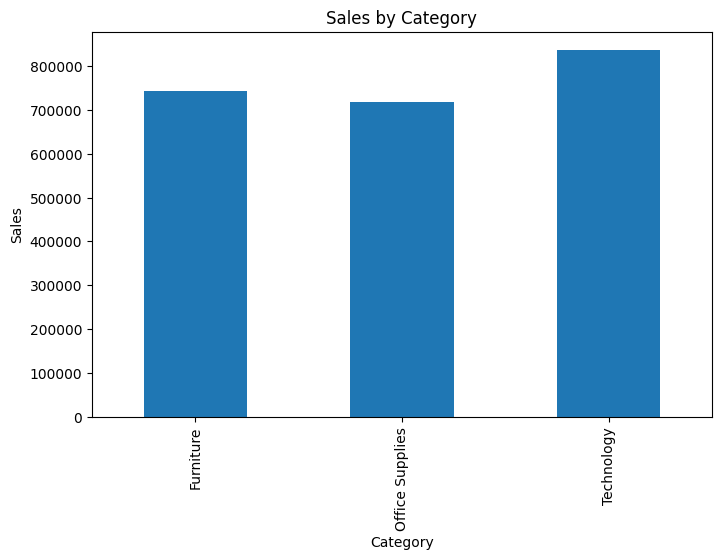

In [ ]:
import matplotlib.pyplot as plt

category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title('Sales by Category')
plt.ylabel('Sales')

plt.savefig("sales_by_category.png", bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import files
files.download("sales_by_category.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("Total Sales =", round(df['Sales'].sum(),2))
print("Total Profit =", round(df['Profit'].sum(),2))
print("Total Orders =", df['Order ID'].nunique())
print("Average Order Value =", round(df['Sales'].mean(),2))

Total Sales = 2297200.86
Total Profit = 286397.02
Total Orders = 5009
Average Order Value = 229.86
